Loading 100...
Loading 101...
Loading 102...
Loading 103...
Loading 104...
Loading 105...
Loading 106...
Loading 107...
Loading 108...
Loading 109...

Dataset shape: (22013, 200)
Class distribution: [12211  9802]
Epoch 1, Loss 22.660
Epoch 2, Loss 10.210
Epoch 3, Loss 7.424
Epoch 4, Loss 5.435
Epoch 5, Loss 5.396
Epoch 6, Loss 4.145
Epoch 7, Loss 3.099
Epoch 8, Loss 3.068
Epoch 9, Loss 2.800
Epoch 10, Loss 2.567
Epoch 11, Loss 2.117
Epoch 12, Loss 1.879
Epoch 13, Loss 1.993
Epoch 14, Loss 1.634
Epoch 15, Loss 1.508
Epoch 16, Loss 1.680
Epoch 17, Loss 1.134
Epoch 18, Loss 1.210
Epoch 19, Loss 2.275
Epoch 20, Loss 1.298

==== SVM ====
Accuracy: 0.9432205314558256
Precision: 0.9703133589884552
Recall: 0.9000509943906171
F1: 0.9338624338624338

==== CNN ====
Accuracy: 0.992505110152169
Precision: 0.9853977844914401
Recall: 0.9979602243753187
F1: 0.9916392196605016


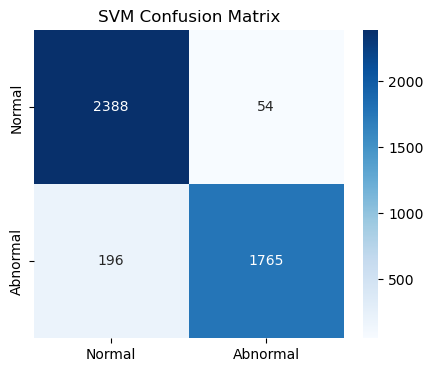

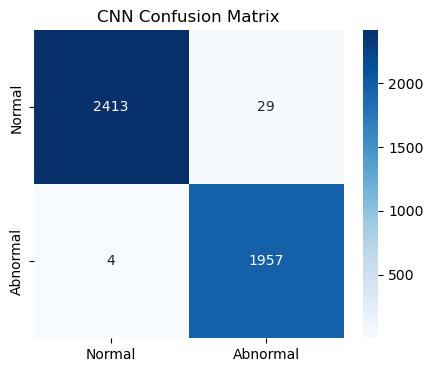

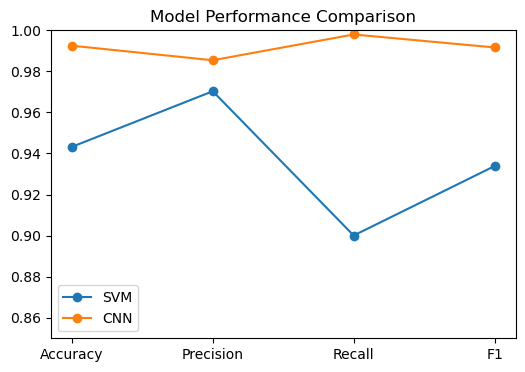

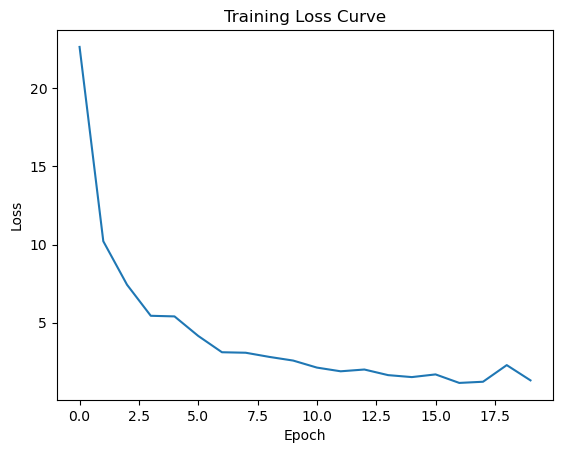

In [2]:
# ===============================
# FINAL FULL VERSION (ALL-IN-ONE)
# ===============================

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import seaborn as sns

# ===============================
# 1. Filter Function
# ===============================
def bandpass_filter(signal, lowcut=0.5, highcut=40, fs=360):
    nyquist = 0.5 * fs
    b, a = butter(4, [lowcut/nyquist, highcut/nyquist], btype='band')
    return filtfilt(b, a, signal)

# ===============================
# 2. Load Multi-record Data
# ===============================
DATA_PATH = "/Users/cathy/Desktop/mitdb"  

record_list = ["100","101","102","103","104","105","106","107","108","109"]

beats, labels_out = [], []
window = 100

for rec in record_list:
    print(f"Loading {rec}...")
    record = wfdb.rdrecord(DATA_PATH + "/" + rec)
    annotation = wfdb.rdann(DATA_PATH + "/" + rec, "atr")

    signal = record.p_signal[:,0]
    signal = bandpass_filter(signal, fs=record.fs)
    signal = (signal - np.mean(signal)) / np.std(signal)

    for r, lab in zip(annotation.sample, annotation.symbol):
        if r > window and r < len(signal)-window:
            beats.append(signal[r-window:r+window])
            labels_out.append(0 if lab=='N' else 1)

X = np.array(beats)
y = np.array(labels_out)

print("\nDataset shape:", X.shape)
print("Class distribution:", np.bincount(y))

# ===============================
# 3. SVM + PCA
# ===============================
X_svm = X.reshape(len(X), -1)

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_svm)
X_test_svm = scaler.transform(X_test_svm)

pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_svm)
X_test_pca = pca.transform(X_test_svm)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_pca, y_train_svm)

y_pred_svm = svm_model.predict(X_test_pca)

# ===============================
# 4. CNN Data
# ===============================
X_cnn = X.reshape(len(X),1,200)

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42, stratify=y
)

class ECGDataset(Dataset):
    def __init__(self,X,y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self,i): return self.X[i], self.y[i]

train_loader = DataLoader(ECGDataset(X_train_cnn,y_train_cnn),batch_size=64,shuffle=True)
test_loader = DataLoader(ECGDataset(X_test_cnn,y_test_cnn),batch_size=64)

# ===============================
# 5. Improved CNN
# ===============================
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1,32,5,padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32,64,5,padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Flatten(),
            nn.Linear(128*25,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,2)
        )
    def forward(self,x): return self.net(x)

model = CNN()


weights = torch.tensor([1.0,8.0])
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(model.parameters(),lr=0.0005)

# ===============================
# 6. Train CNN + Loss
# ===============================
loss_history = []

for epoch in range(20):
    total=0
    model.train()
    for xb,yb in train_loader:
        out = model(xb)
        loss = criterion(out,yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    loss_history.append(total)
    print(f"Epoch {epoch+1}, Loss {total:.3f}")

# ===============================
# 7. Evaluate Function
# ===============================
def evaluate(y_true,y_pred,name):
    print("\n====",name,"====")
    acc = accuracy_score(y_true,y_pred)
    pre = precision_score(y_true,y_pred)
    rec = recall_score(y_true,y_pred)
    f1 = f1_score(y_true,y_pred)
    print("Accuracy:",acc)
    print("Precision:",pre)
    print("Recall:",rec)
    print("F1:",f1)
    return acc,pre,rec,f1,confusion_matrix(y_true,y_pred)

# CNN
model.eval()
yt, yp = [], []
with torch.no_grad():
    for xb,yb in test_loader:
        pred = torch.argmax(model(xb),1)
        yt += yb.tolist()
        yp += pred.tolist()

svm_metrics = evaluate(y_test_svm,y_pred_svm,"SVM")
cnn_metrics = evaluate(yt,yp,"CNN")

# ===============================
# 8. Confusion Matrix Plot
# ===============================
def plot_cm(cm,title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
                xticklabels=["Normal","Abnormal"],
                yticklabels=["Normal","Abnormal"])
    plt.title(title)

    plt.savefig("confusion matrix.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_cm(svm_metrics[4],"SVM Confusion Matrix")
plot_cm(cnn_metrics[4],"CNN Confusion Matrix")

# ===============================
# 9. Performance Comparison
# ===============================
labels_plot = ['Accuracy','Precision','Recall','F1']

plt.figure(figsize=(6,4))
plt.plot(labels_plot, svm_metrics[:4], marker='o', label='SVM')
plt.plot(labels_plot, cnn_metrics[:4], marker='o', label='CNN')
plt.title("Model Performance Comparison")
plt.ylim(0.85,1.0)
plt.legend()

plt.savefig("model_performance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# ===============================
# 10. Loss Curve
# ===============================
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig("loss_curve.png", dpi=300, bbox_inches='tight')
plt.show()

Loading 100...
Loading 101...
Loading 102...
Loading 103...
Loading 104...
Loading 105...
Loading 106...
Loading 107...
Loading 108...
Loading 109...
Dataset shape: (22013, 200)
Class distribution: [12211  9802]
Epoch 1, Train Loss: 20.716, Val Loss: 2.538
Epoch 2, Train Loss: 9.595, Val Loss: 1.604
Epoch 3, Train Loss: 8.241, Val Loss: 1.213
Epoch 4, Train Loss: 5.438, Val Loss: 1.188
Epoch 5, Train Loss: 4.953, Val Loss: 1.254
Epoch 6, Train Loss: 4.152, Val Loss: 0.986
Epoch 7, Train Loss: 3.508, Val Loss: 1.337
Epoch 8, Train Loss: 2.830, Val Loss: 0.867
Epoch 9, Train Loss: 2.540, Val Loss: 0.790
Epoch 10, Train Loss: 2.353, Val Loss: 0.860
Epoch 11, Train Loss: 2.090, Val Loss: 0.894
Epoch 12, Train Loss: 2.127, Val Loss: 0.957
Epoch 13, Train Loss: 1.692, Val Loss: 1.286
Epoch 14, Train Loss: 1.681, Val Loss: 0.993
Epoch 15, Train Loss: 1.063, Val Loss: 1.271
Epoch 16, Train Loss: 1.655, Val Loss: 0.868
Epoch 17, Train Loss: 1.569, Val Loss: 1.384
Epoch 18, Train Loss: 1.502, Va

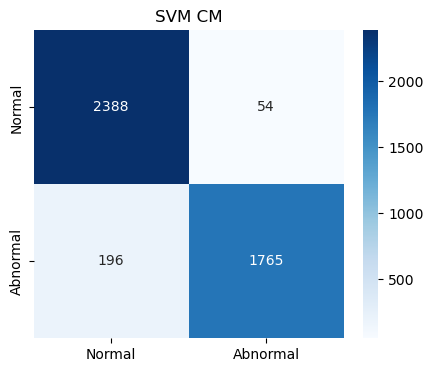

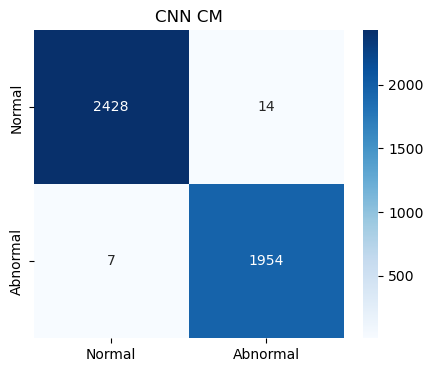

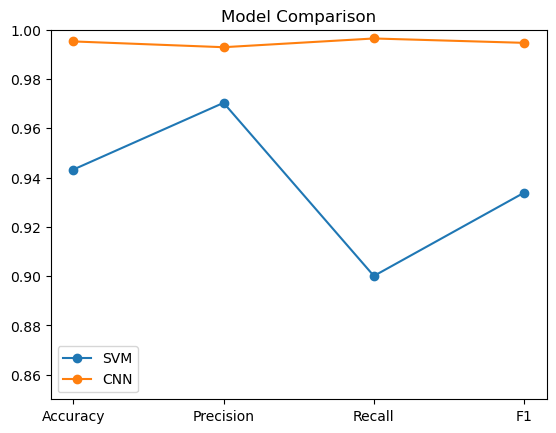

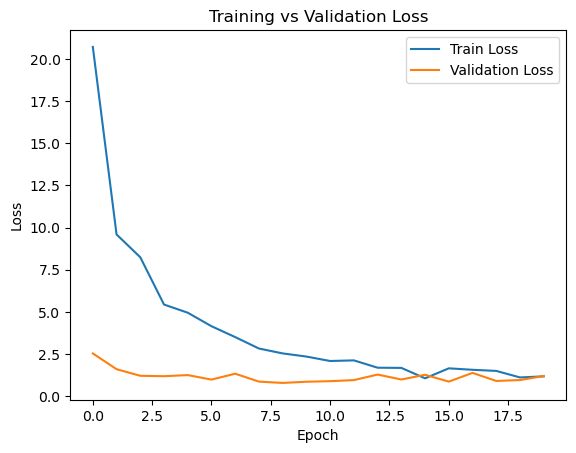

In [4]:
# ==============================
# FINAL FULL VERSION (ALL-IN-ONE)
# ==============================

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import seaborn as sns

# ==============================
# 1. Filter Function
# ==============================

def bandpass_filter(signal, lowcut=0.5, highcut=40, fs=360):
    nyquist = 0.5 * fs
    b, a = butter(4, [lowcut/nyquist, highcut/nyquist], btype='band')
    return filtfilt(b, a, signal)

# ==============================
# 2. Load Data
# ==============================

DATA_PATH = "/Users/cathy/Desktop/mitdb"
record_list = ["100","101","102","103","104","105","106","107","108","109"]

beats, labels_out = [], []
window = 100

for rec in record_list:
    print(f"Loading {rec}...")
    record = wfdb.rdrecord(DATA_PATH + "/" + rec)
    annotation = wfdb.rdann(DATA_PATH + "/" + rec, "atr")

    signal = record.p_signal[:,0]
    signal = bandpass_filter(signal, fs=record.fs)
    signal = (signal - np.mean(signal)) / np.std(signal)

    for r, lab in zip(annotation.sample, annotation.symbol):
        if r > window and r < len(signal) - window:
            beats.append(signal[r-window:r+window])
            labels_out.append(0 if lab=='N' else 1)

X = np.array(beats)
y = np.array(labels_out)

print("Dataset shape:", X.shape)
print("Class distribution:", np.bincount(y))

# ==============================
# 3. SVM + PCA
# ==============================

X_svm = X.reshape(len(X), -1)

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_svm)
X_test_svm = scaler.transform(X_test_svm)

pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_svm)
X_test_pca = pca.transform(X_test_svm)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_pca, y_train_svm)
y_pred_svm = svm_model.predict(X_test_pca)

# ==============================
# 4. CNN Data (加 validation)
# ==============================

X_cnn = X.reshape(len(X),1,200)

# train + test
X_temp, X_test_cnn, y_temp, y_test_cnn = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42, stratify=y
)

# train + validation
X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

class ECGDataset(Dataset):
    def __init__(self,X,y):
        self.X = torch.tensor(X,dtype=torch.float32)
        self.y = torch.tensor(y,dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,i):
        return self.X[i], self.y[i]

train_loader = DataLoader(ECGDataset(X_train_cnn,y_train_cnn),batch_size=64,shuffle=True)
val_loader   = DataLoader(ECGDataset(X_val_cnn,y_val_cnn),batch_size=64)
test_loader  = DataLoader(ECGDataset(X_test_cnn,y_test_cnn),batch_size=64)

# ==============================
# 5. CNN Model
# ==============================

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1,32,5,padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32,64,5,padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Flatten(),
            nn.Linear(128*25,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,2)
        )

    def forward(self,x):
        return self.net(x)

model = CNN()

weights = torch.tensor([1.0,8.0])
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(),lr=0.0005)

# ==============================
# 6. Train + Validation Loss
# ==============================

train_loss_history = []
val_loss_history = []

for epoch in range(20):
    model.train()
    train_loss = 0

    for xb,yb in train_loader:
        out = model(xb)
        loss = criterion(out,yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss_history.append(train_loss)

    # validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb,yb in val_loader:
            out = model(xb)
            loss = criterion(out,yb)
            val_loss += loss.item()

    val_loss_history.append(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.3f}, Val Loss: {val_loss:.3f}")

# ==============================
# 7. Evaluation
# ==============================

def evaluate(y_true,y_pred,name):
    print("\n----",name,"----")
    acc = accuracy_score(y_true,y_pred)
    pre = precision_score(y_true,y_pred)
    rec = recall_score(y_true,y_pred)
    f1  = f1_score(y_true,y_pred)

    print("Accuracy:",acc)
    print("Precision:",pre)
    print("Recall:",rec)
    print("F1:",f1)

    return acc,pre,rec,f1,confusion_matrix(y_true,y_pred)

# CNN
model.eval()
yt,yp = [],[]

with torch.no_grad():
    for xb,yb in test_loader:
        pred = torch.argmax(model(xb),1)
        yt += yb.tolist()
        yp += pred.tolist()

svm_metrics = evaluate(y_test_svm,y_pred_svm,"SVM")
cnn_metrics = evaluate(yt,yp,"CNN")

# ==============================
# 8. Confusion Matrix
# ==============================

def plot_cm(cm,title):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
                xticklabels=["Normal","Abnormal"],
                yticklabels=["Normal","Abnormal"])
    plt.title(title)
    plt.show()

plot_cm(svm_metrics[4],"SVM CM")
plot_cm(cnn_metrics[4],"CNN CM")

# ==============================
# 9. Performance Comparison
# ==============================

labels_plot = ['Accuracy','Precision','Recall','F1']

plt.plot(labels_plot,svm_metrics[:4],marker='o',label='SVM')
plt.plot(labels_plot,cnn_metrics[:4],marker='o',label='CNN')
plt.title("Model Comparison")
plt.ylim(0.85,1.0)
plt.legend()
plt.show()

# ==============================
# 10. LOSS CURVE（关键‼️）
# ==============================

plt.plot(train_loss_history,label="Train Loss")
plt.plot(val_loss_history,label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Loading 100...
Loading 101...
Loading 102...
Loading 103...
Loading 104...
Loading 105...
Loading 106...
Loading 107...
Loading 108...
Loading 109...
Dataset shape: (22013, 200)
Epoch 1: Train=0.0952, Val=0.0420
Epoch 2: Train=0.0425, Val=0.0293
Epoch 3: Train=0.0289, Val=0.0239
Epoch 4: Train=0.0267, Val=0.0192
Epoch 5: Train=0.0223, Val=0.0178
Epoch 6: Train=0.0160, Val=0.0169
Epoch 7: Train=0.0152, Val=0.0145
Epoch 8: Train=0.0148, Val=0.0167
Epoch 9: Train=0.0124, Val=0.0173
Epoch 10: Train=0.0091, Val=0.0133
Epoch 11: Train=0.0098, Val=0.0148
Epoch 12: Train=0.0086, Val=0.0130
Epoch 13: Train=0.0096, Val=0.0188
Epoch 14: Train=0.0083, Val=0.0147
Epoch 15: Train=0.0073, Val=0.0171
Epoch 16: Train=0.0061, Val=0.0168
Epoch 17: Train=0.0077, Val=0.0124
Epoch 18: Train=0.0061, Val=0.0189
Epoch 19: Train=0.0058, Val=0.0136
Epoch 20: Train=0.0041, Val=0.0169

SVM Results:
Accuracy: 0.9432205314558256
Precision: 0.9703133589884552
Recall: 0.9000509943906171
F1: 0.9338624338624338

CNN Res

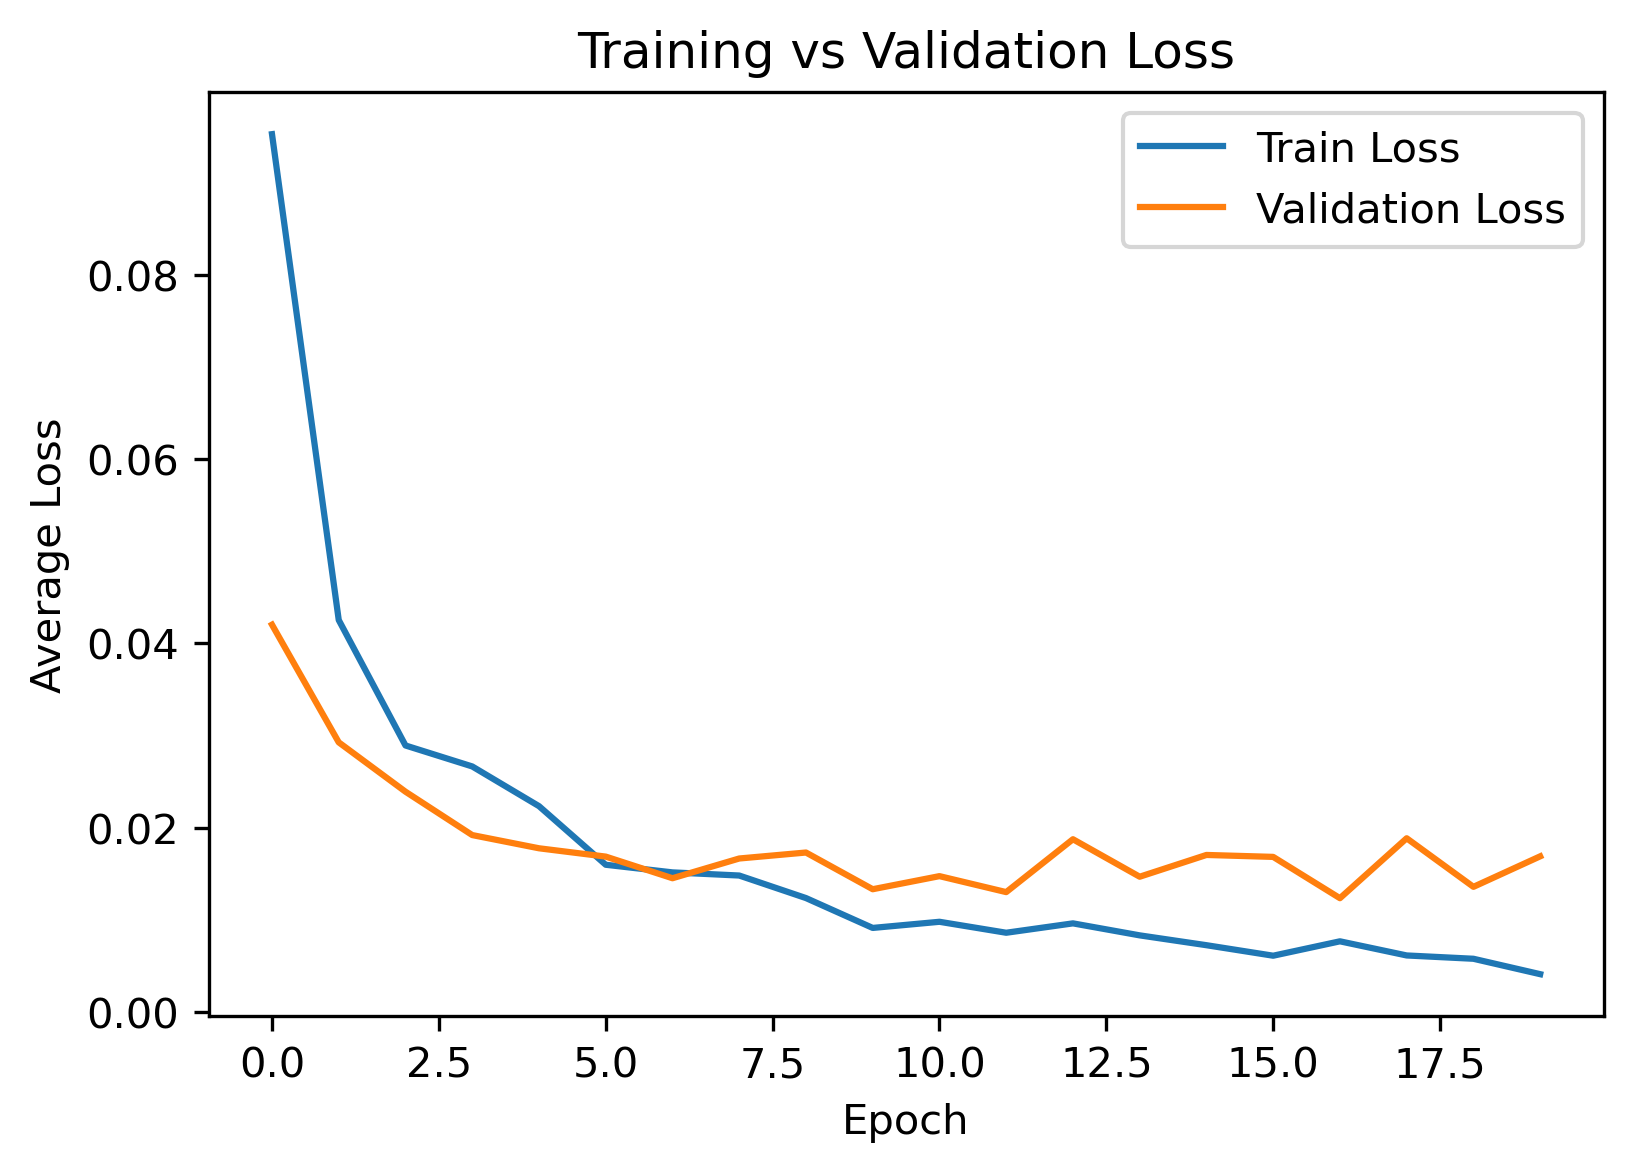

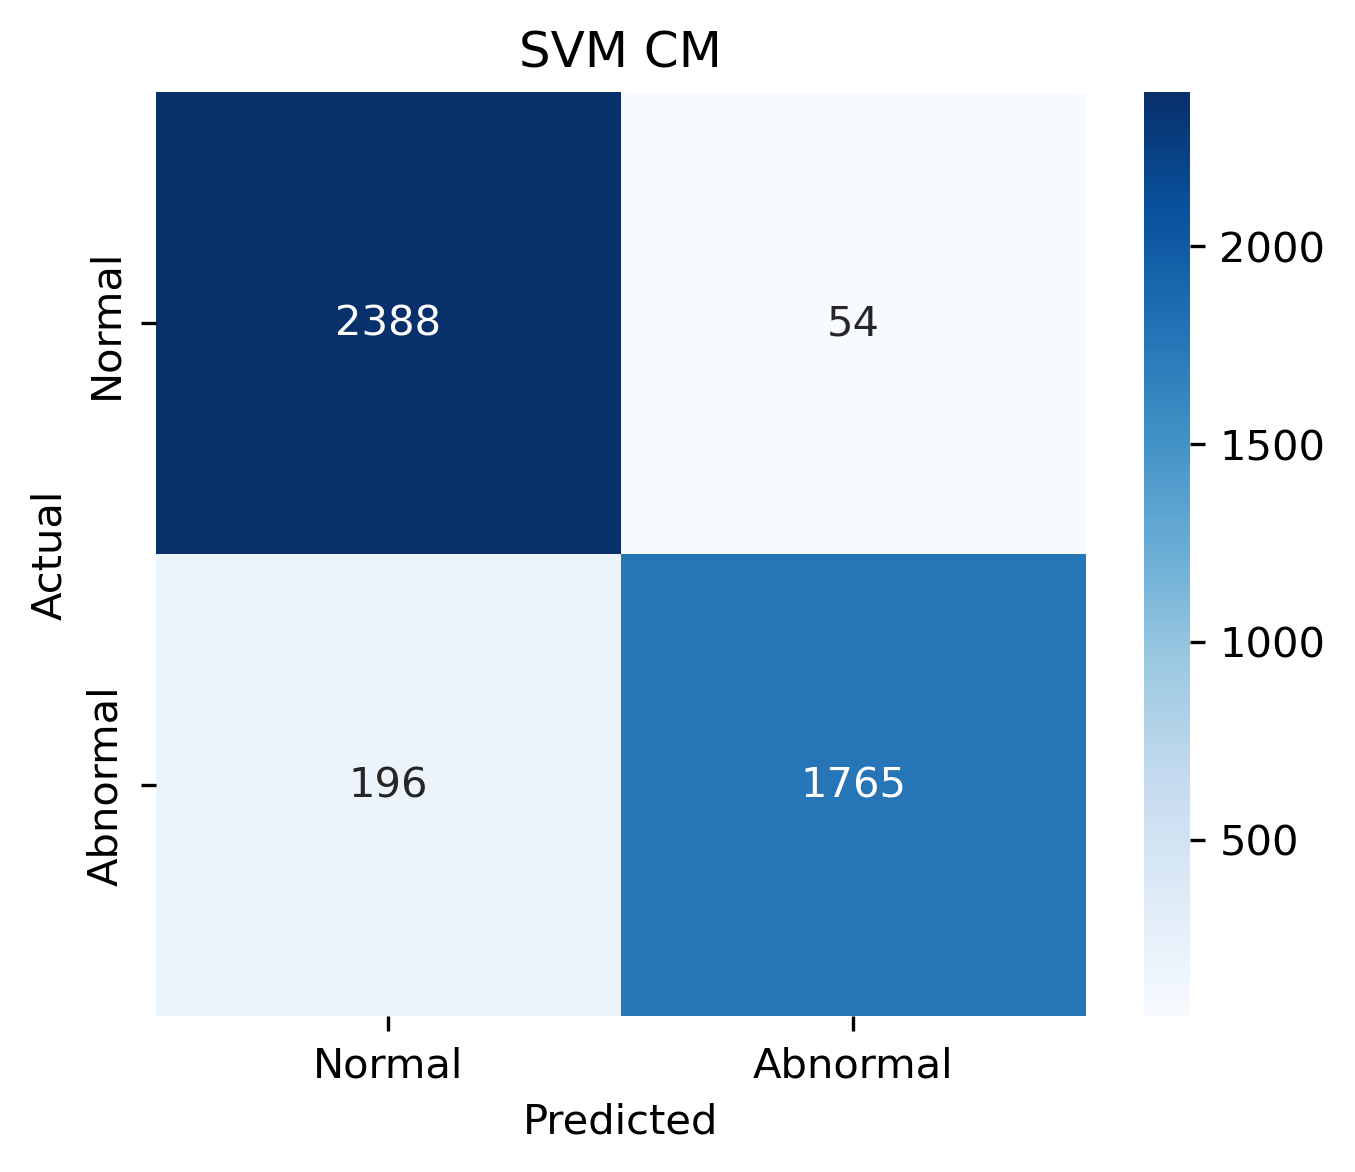

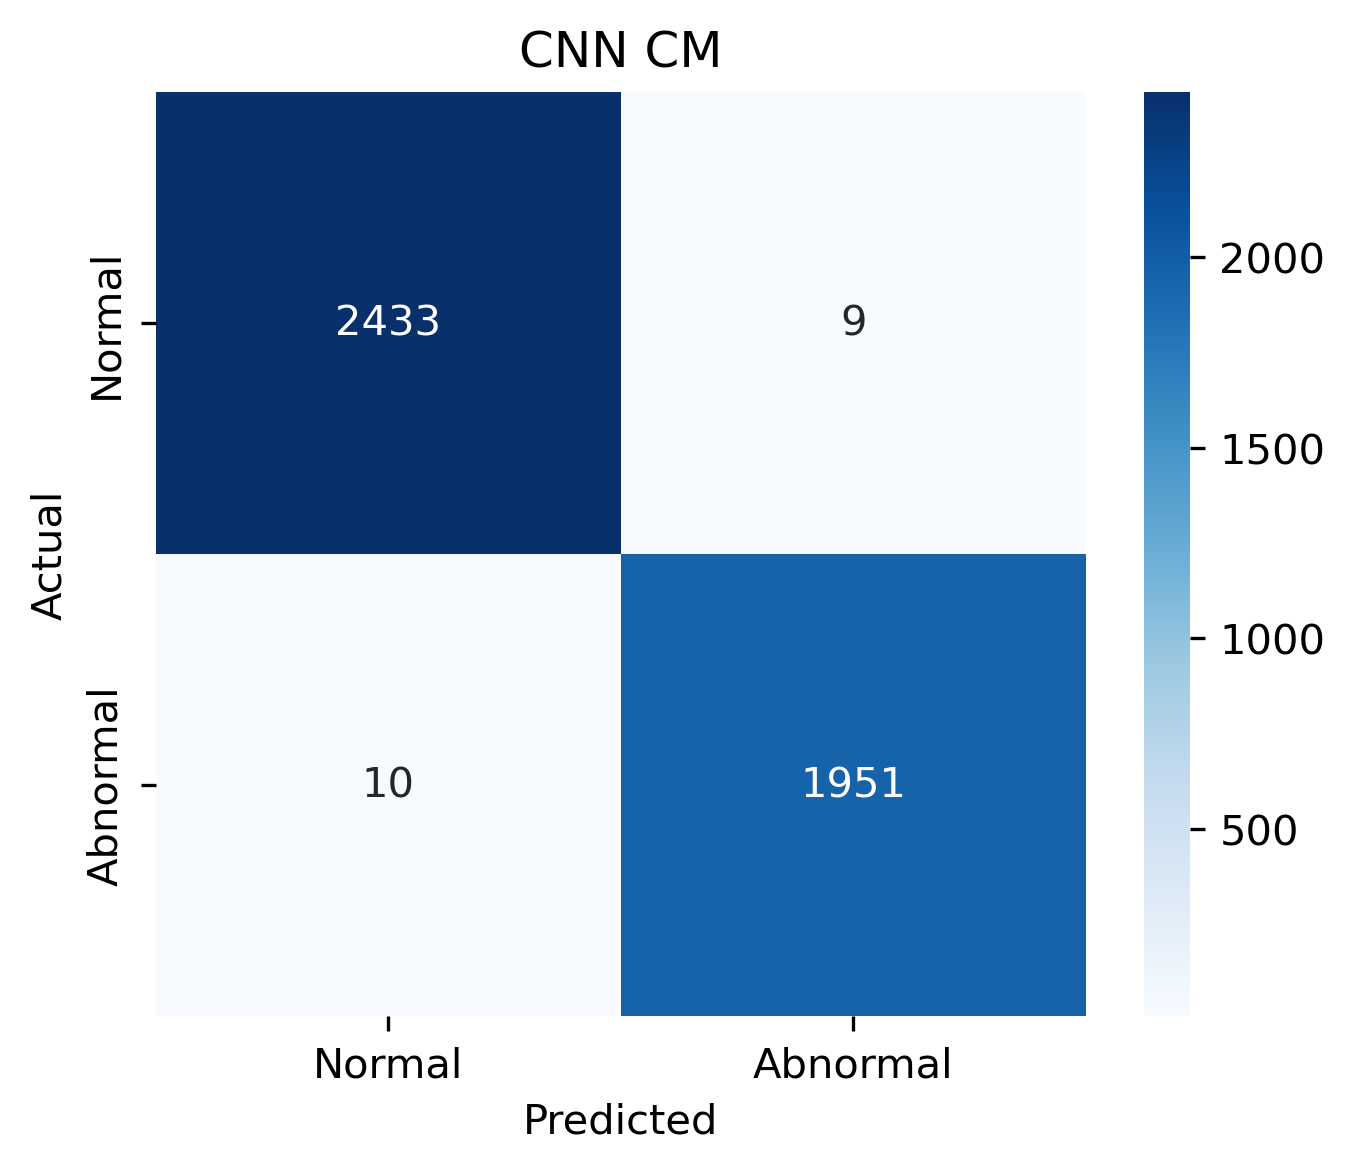

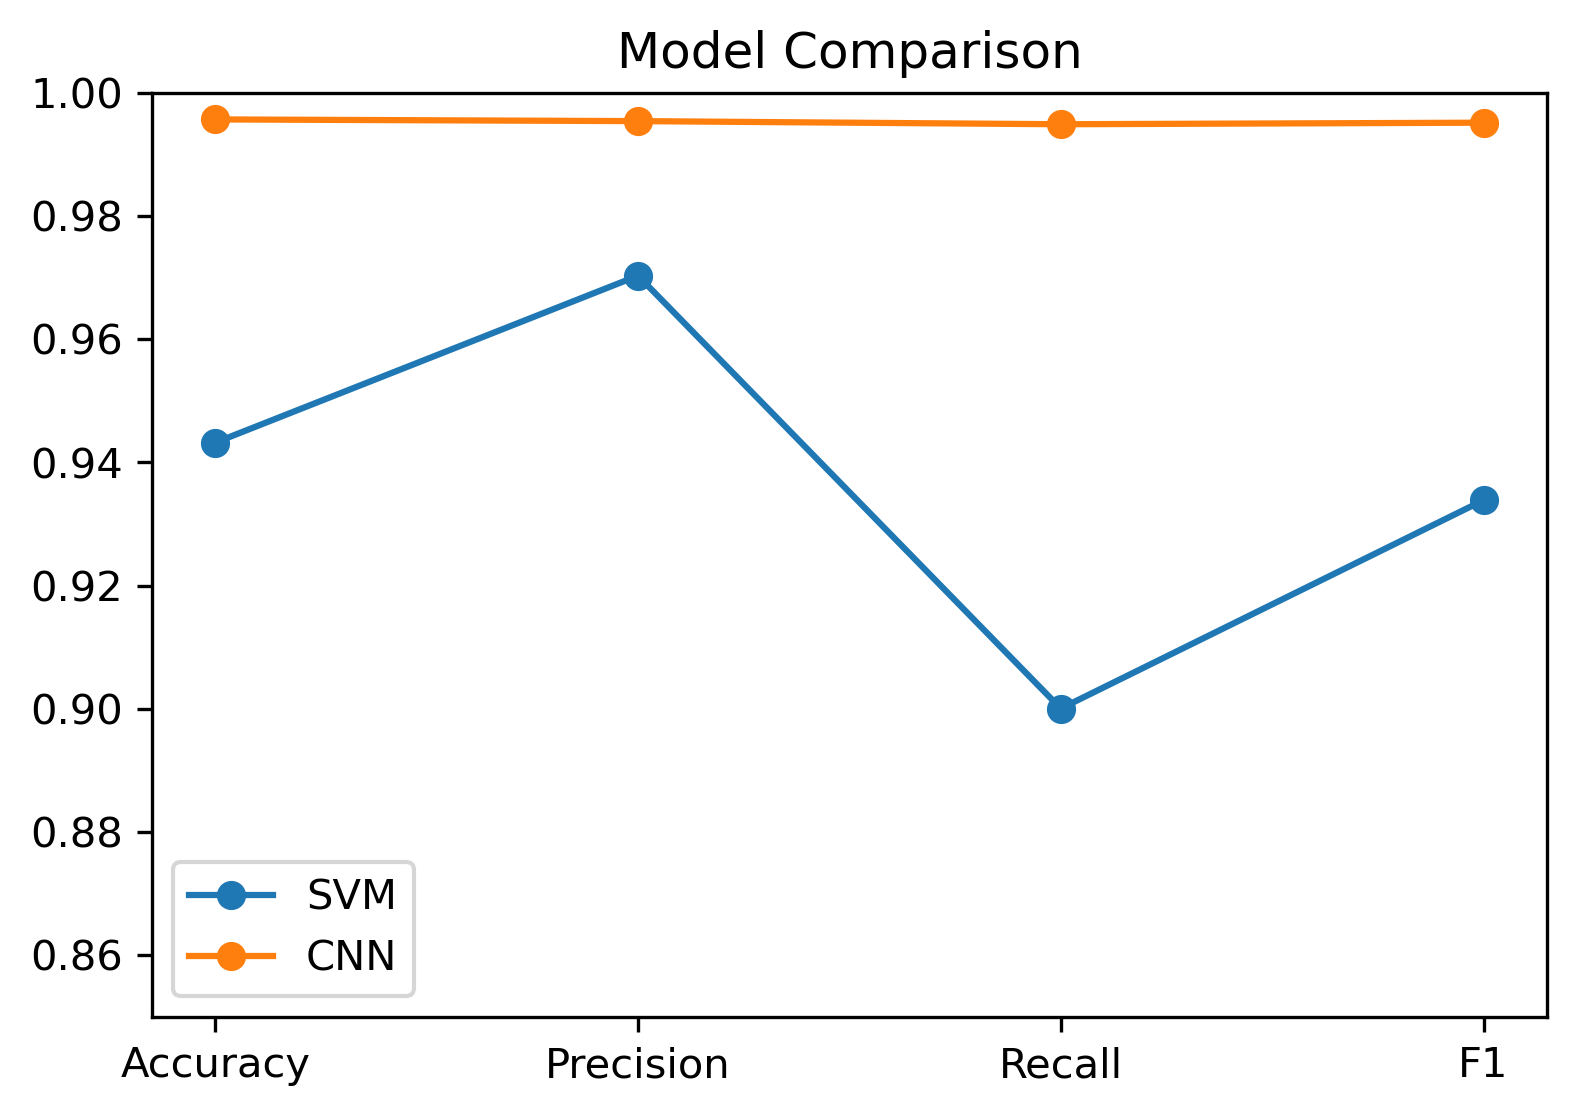

In [5]:
# ============================================
# ECG Classification FINAL VERSION
# Features:
# - Average loss (per-sample)
# - Train / Validation / Test
# - High-resolution figure saving
# - SVM vs CNN comparison
# - Ablation support (toggle preprocessing)
# ============================================

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import seaborn as sns

# ============================================
# 0. Settings (Figure Saving)
# ============================================

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

os.makedirs("figures", exist_ok=True)

# ============================================
# 1. Bandpass Filter
# ============================================

def bandpass_filter(signal, lowcut=0.5, highcut=40, fs=360):
    nyquist = 0.5 * fs
    b, a = butter(4, [lowcut/nyquist, highcut/nyquist], btype='band')
    return filtfilt(b, a, signal)

# ============================================
# 2. Load Data
# ============================================

record_list = ["100","101","102","103","104","105","106","107","108","109"]

beats, labels_out = [], []
window = 100

for rec in record_list:
    print(f"Loading {rec}...")

    record = wfdb.rdrecord(rec, pn_dir='mitdb')
    annotation = wfdb.rdann(rec, 'atr', pn_dir='mitdb')

    signal = record.p_signal[:,0]

    # ===== Ablation: comment this line to remove preprocessing =====
    signal = bandpass_filter(signal, fs=record.fs)

    # Normalization
    signal = (signal - np.mean(signal)) / np.std(signal)

    for r, lab in zip(annotation.sample, annotation.symbol):
        if r > window and r < len(signal) - window:
            beats.append(signal[r-window:r+window])
            labels_out.append(0 if lab=='N' else 1)

X = np.array(beats)
y = np.array(labels_out)

print("Dataset shape:", X.shape)

# ============================================
# 3. SVM
# ============================================

X_svm = X.reshape(len(X), -1)

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_svm)
X_test_svm = scaler.transform(X_test_svm)

pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_svm)
X_test_pca = pca.transform(X_test_svm)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_pca, y_train_svm)
y_pred_svm = svm_model.predict(X_test_pca)

# ============================================
# 4. CNN Data
# ============================================

X_cnn = X.reshape(len(X),1,200)

X_temp, X_test_cnn, y_temp, y_test_cnn = train_test_split(
    X_cnn, y, test_size=0.2, stratify=y, random_state=42
)

X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42
)

class ECGDataset(Dataset):
    def __init__(self,X,y):
        self.X = torch.tensor(X,dtype=torch.float32)
        self.y = torch.tensor(y,dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,i):
        return self.X[i], self.y[i]

train_loader = DataLoader(ECGDataset(X_train_cnn,y_train_cnn),batch_size=64,shuffle=True)
val_loader   = DataLoader(ECGDataset(X_val_cnn,y_val_cnn),batch_size=64)
test_loader  = DataLoader(ECGDataset(X_test_cnn,y_test_cnn),batch_size=64)

# ============================================
# 5. CNN Model
# ============================================

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1,32,5,padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32,64,5,padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Flatten(),
            nn.Linear(128*25,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,2)
        )

    def forward(self,x):
        return self.net(x)

model = CNN()

weights = torch.tensor([1.0,8.0])
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(),lr=0.0005)

# ============================================
# 6. Training (Average Loss)
# ============================================

train_loss_history = []
val_loss_history = []

for epoch in range(20):
    model.train()
    train_loss = 0

    for xb,yb in train_loader:
        out = model(xb)
        loss = criterion(out,yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)
    train_loss_history.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb,yb in val_loader:
            out = model(xb)
            loss = criterion(out,yb)
            val_loss += loss.item() * xb.size(0)

    val_loss /= len(val_loader.dataset)
    val_loss_history.append(val_loss)

    print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")

# ============================================
# 7. Evaluation
# ============================================

def evaluate(y_true,y_pred,name):
    print(f"\n{name} Results:")
    acc = accuracy_score(y_true,y_pred)
    pre = precision_score(y_true,y_pred)
    rec = recall_score(y_true,y_pred)
    f1  = f1_score(y_true,y_pred)

    print("Accuracy:",acc)
    print("Precision:",pre)
    print("Recall:",rec)
    print("F1:",f1)

    return acc,pre,rec,f1,confusion_matrix(y_true,y_pred)

# CNN Test
model.eval()
yt,yp = [],[]

with torch.no_grad():
    for xb,yb in test_loader:
        pred = torch.argmax(model(xb),1)
        yt += yb.tolist()
        yp += pred.tolist()

svm_metrics = evaluate(y_test_svm,y_pred_svm,"SVM")
cnn_metrics = evaluate(yt,yp,"CNN")

# ============================================
# 8. Loss Curve (Save)
# ============================================

plt.figure(figsize=(5,3))
plt.plot(train_loss_history,label="Train Loss")
plt.plot(val_loss_history,label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig("figures/loss_curve.png", bbox_inches='tight')
plt.show()

# ============================================
# 9. Confusion Matrix (Save)
# ============================================

def plot_cm(cm,title,filename):
    plt.figure(figsize=(5,3))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
                xticklabels=["Normal","Abnormal"],
                yticklabels=["Normal","Abnormal"])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.savefig(filename, bbox_inches='tight')
    plt.show()

plot_cm(svm_metrics[4], "SVM CM", "figures/svm_cm.png")
plot_cm(cnn_metrics[4], "CNN CM", "figures/cnn_cm.png")

# ============================================
# 10. Model Comparison (Save)
# ============================================

labels_plot = ['Accuracy','Precision','Recall','F1']

plt.figure(figsize=(6,4))
plt.plot(labels_plot, svm_metrics[:4], marker='o', label='SVM')
plt.plot(labels_plot, cnn_metrics[:4], marker='o', label='CNN')

plt.title("Model Comparison")
plt.ylim(0.85,1.0)
plt.legend()

plt.savefig("figures/model_comparison.png", bbox_inches='tight')
plt.show()

Loading 100...
Loading 101...
Loading 102...
Loading 103...
Loading 104...
Loading 105...
Loading 106...
Loading 107...
Loading 108...
Loading 109...
Dataset shape: (22013, 200)
Epoch 1: Train=0.1079, Val=0.0549
Epoch 2: Train=0.0497, Val=0.0339
Epoch 3: Train=0.0371, Val=0.0282
Epoch 4: Train=0.0306, Val=0.0231
Epoch 5: Train=0.0249, Val=0.0186
Epoch 6: Train=0.0212, Val=0.0176
Epoch 7: Train=0.0189, Val=0.0224
Epoch 8: Train=0.0155, Val=0.0145
Epoch 9: Train=0.0150, Val=0.0149
Epoch 10: Train=0.0111, Val=0.0137
Epoch 11: Train=0.0120, Val=0.0143
Epoch 12: Train=0.0105, Val=0.0205
Epoch 13: Train=0.0109, Val=0.0181
Epoch 14: Train=0.0093, Val=0.0195
Epoch 15: Train=0.0091, Val=0.0187
Epoch 16: Train=0.0062, Val=0.0190
Epoch 17: Train=0.0066, Val=0.0208
Epoch 18: Train=0.0059, Val=0.0162
Epoch 19: Train=0.0038, Val=0.0183
Epoch 20: Train=0.0056, Val=0.0133

SVM Results:
Accuracy: 0.9432205314558256
Precision: 0.9703133589884552
Recall: 0.9000509943906171
F1: 0.9338624338624338

CNN Res

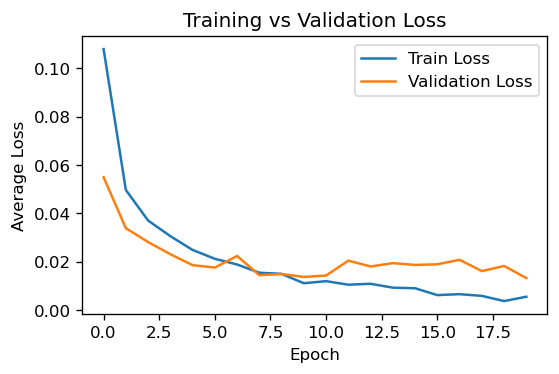

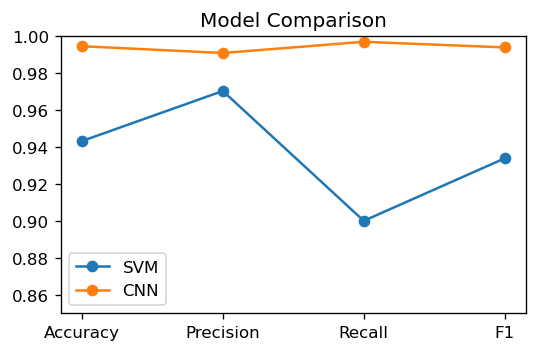

In [6]:
# ============================================
# ECG Classification FINAL VERSION
# Features:
# - Average loss (per-sample)
# - Proper Train / Validation / Test split
# - Correct loss curve (Train vs Validation)
# - SVM vs CNN comparison
# - Clean figures (good size for PPT)
# ============================================

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import seaborn as sns

# ============================================
# 0. Figure settings (important for size)
# ============================================

plt.rcParams['figure.dpi'] = 120      # display size
plt.rcParams['savefig.dpi'] = 150     # saved image quality

os.makedirs("figures", exist_ok=True)

# ============================================
# 1. Bandpass Filter (Preprocessing)
# ============================================

def bandpass_filter(signal, lowcut=0.5, highcut=40, fs=360):
    nyquist = 0.5 * fs
    b, a = butter(4, [lowcut/nyquist, highcut/nyquist], btype='band')
    return filtfilt(b, a, signal)

# ============================================
# 2. Load Dataset (MIT-BIH)
# ============================================

record_list = ["100","101","102","103","104","105","106","107","108","109"]

beats, labels_out = [], []
window = 100

for rec in record_list:
    print(f"Loading {rec}...")

    record = wfdb.rdrecord(rec, pn_dir='mitdb')
    annotation = wfdb.rdann(rec, 'atr', pn_dir='mitdb')

    signal = record.p_signal[:,0]

    # Ablation: comment this line to remove preprocessing
    signal = bandpass_filter(signal, fs=record.fs)

    # normalization
    signal = (signal - np.mean(signal)) / np.std(signal)

    for r, lab in zip(annotation.sample, annotation.symbol):
        if r > window and r < len(signal) - window:
            beats.append(signal[r-window:r+window])
            labels_out.append(0 if lab=='N' else 1)

X = np.array(beats)
y = np.array(labels_out)

print("Dataset shape:", X.shape)

# ============================================
# 3. SVM (Baseline Model)
# ============================================

X_svm = X.reshape(len(X), -1)

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_svm)
X_test_svm = scaler.transform(X_test_svm)

pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_svm)
X_test_pca = pca.transform(X_test_svm)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_pca, y_train_svm)
y_pred_svm = svm_model.predict(X_test_pca)

# ============================================
# 4. CNN Data (Train / Validation / Test)
# ============================================

X_cnn = X.reshape(len(X),1,200)

X_temp, X_test_cnn, y_temp, y_test_cnn = train_test_split(
    X_cnn, y, test_size=0.2, stratify=y, random_state=42
)

X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=42
)

class ECGDataset(Dataset):
    def __init__(self,X,y):
        self.X = torch.tensor(X,dtype=torch.float32)
        self.y = torch.tensor(y,dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,i):
        return self.X[i], self.y[i]

train_loader = DataLoader(ECGDataset(X_train_cnn,y_train_cnn),batch_size=64,shuffle=True)
val_loader   = DataLoader(ECGDataset(X_val_cnn,y_val_cnn),batch_size=64)
test_loader  = DataLoader(ECGDataset(X_test_cnn,y_test_cnn),batch_size=64)

# ============================================
# 5. CNN Model
# ============================================

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1,32,5,padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32,64,5,padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Flatten(),
            nn.Linear(128*25,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,2)
        )

    def forward(self,x):
        return self.net(x)

model = CNN()

weights = torch.tensor([1.0,8.0])
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(),lr=0.0005)

# ============================================
# 6. Training (Average Loss per Sample)
# ============================================

train_loss_history = []
val_loss_history = []

for epoch in range(20):
    model.train()
    train_loss = 0

    for xb,yb in train_loader:
        out = model(xb)
        loss = criterion(out,yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)
    train_loss_history.append(train_loss)

    # validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb,yb in val_loader:
            out = model(xb)
            loss = criterion(out,yb)
            val_loss += loss.item() * xb.size(0)

    val_loss /= len(val_loader.dataset)
    val_loss_history.append(val_loss)

    print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")

# ============================================
# 7. Evaluation (Test Set Only)
# ============================================

def evaluate(y_true,y_pred,name):
    print(f"\n{name} Results:")
    acc = accuracy_score(y_true,y_pred)
    pre = precision_score(y_true,y_pred)
    rec = recall_score(y_true,y_pred)
    f1  = f1_score(y_true,y_pred)

    print("Accuracy:",acc)
    print("Precision:",pre)
    print("Recall:",rec)
    print("F1:",f1)

    return acc,pre,rec,f1,confusion_matrix(y_true,y_pred)

model.eval()
yt,yp = [],[]

with torch.no_grad():
    for xb,yb in test_loader:
        pred = torch.argmax(model(xb),1)
        yt += yb.tolist()
        yp += pred.tolist()

svm_metrics = evaluate(y_test_svm,y_pred_svm,"SVM")
cnn_metrics = evaluate(yt,yp,"CNN")

# ============================================
# 8. Loss Curve (Correct)
# ============================================

plt.figure(figsize=(5,3))

plt.plot(train_loss_history,label="Train Loss")
plt.plot(val_loss_history,label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig("figures/loss_curve.png", bbox_inches='tight')
plt.show()

# ============================================
# 9. Model Comparison
# ============================================

labels_plot = ['Accuracy','Precision','Recall','F1']

plt.figure(figsize=(5,3))

plt.plot(labels_plot, svm_metrics[:4], marker='o', label='SVM')
plt.plot(labels_plot, cnn_metrics[:4], marker='o', label='CNN')

plt.title("Model Comparison")
plt.ylim(0.85,1.0)
plt.legend()

plt.savefig("figures/model_comparison.png", bbox_inches='tight')
plt.show()